# GO

In [2]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import ListedColormap
from natsort import natsorted

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path
input_path = os.path.join(expr_path, 'DE analysis')

In [4]:
# Input
adata = sc.read_h5ad(os.path.join(expr_path, '2025-07-03-finalized-ct-rgn.h5ad'))
adata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta', 'level_3_label', 'coronal_position_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'leve

## Color palettes

In [5]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

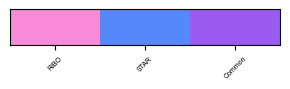

In [6]:
# RIBO, STAR, Common
protocol_order = ['RIBO', 'STAR', 'Common']
protocol_pl = sns.color_palette(['#f78bda', '#5788fa', '#9b5bf0'])
protocol_cmap = ListedColormap(protocol_pl.as_hex())
sns.palplot(protocol_pl)
plt.xticks(range(len(protocol_order)), protocol_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'test.pdf'))
plt.show()

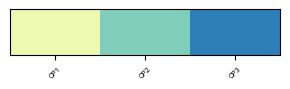

In [7]:
# CP1, CP2, CP3
cp_order = ['CP1', 'CP2', 'CP3']
cp_pl = sns.color_palette(['#edf8b1', '#7fcdbb', '#2c7fb8'])
cp_cmap = ListedColormap(cp_pl.as_hex())
sns.palplot(cp_pl)
plt.xticks(range(len(cp_order)), cp_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

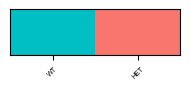

In [8]:
# WT, HET
condition_order = ['WT', 'HET']
condition_pl = sns.color_palette(['#00bfc4', '#f8766d'])
condition_cmap = ListedColormap(condition_pl.as_hex())
sns.palplot(condition_pl)
plt.xticks(range(len(condition_order)), condition_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

In [528]:
sns.color_palette('mako_r')

[(0.54578602, 0.8544913, 0.69848331),
 (0.25187832, 0.71827158, 0.67872193),
 (0.20344718, 0.56074869, 0.65649508),
 (0.21607792, 0.39736958, 0.61948028),
 (0.25307401, 0.23772973, 0.48316271),
 (0.18195582, 0.11955283, 0.23136943)]

## Load DEG output

In [306]:
# Load all sheets from the Excel file into a dictionary
l2_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_2_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l2_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l2_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [11]:
# Load all sheets from the Excel file into a dictionary
l3_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_3_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l3_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l3_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

## GO related

In [9]:
import gseapy as gp

In [7]:
# load custom gene list
go_annot_df = pd.read_excel(os.path.join(base_path, 'documents', 'c5.all.v7.2.symbols.xlsx'), header=None)
go_annot_df = go_annot_df.drop([1], axis=1)
go_annot_df = go_annot_df.T
go_annot_df.columns = go_annot_df.iloc[0]
go_annot_df = go_annot_df.drop([0])

GO_dict = {}
for curruent_term in go_annot_df.columns:
    GO_dict[curruent_term] = [gene for gene in go_annot_df[curruent_term].dropna()]

In [10]:
# load gwas gene list
gwas_df = pd.read_excel(os.path.join(base_path, 'documents', 'S2_List of curated gene-sets.xlsx'), header=[0, 1])
GWAS_dict = {}
for current_column in gwas_df.columns:
    current_term = current_column[0] + '_' + current_column[1]
    GWAS_dict[current_term] = [gene for gene in gwas_df[current_column].dropna().str.upper()]

In [23]:
# Load all sheets from the Excel file into a dictionary
l2_deg_file_path = os.path.join(input_path, '2025-04-09_level_2_DEG.xlsx')
excel_data = pd.ExcelFile(l2_deg_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l2_deg_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [23]:
ARG_list = [
    'Egr4', 'Fosb', 'Npas4', 'Fos', 'Btg2', 'Ier2', 'Amigo3', 'Egr3', 'Dusp1', 'Klf4', 
    'Arc', 'Gadd45g', 'Ppp1r15a', 'Egr2', 'Dusp5', 'Maff', 'Junb', 'Nr4a1', 'Egr1', 'Fndc9', 
    'Scg2', 'Glt28d2', 'Mbnl2', 'Maml3', 'Csrnp1', 'Sv2c', 'Hsd17b12', 'Crhbp', 'Col10a1', 'Gch1', 
    'Tac1', 'Errfi1', 'C2cd4b', 'Prok2', 'Slc2a3', 'Cartpt', 'Kcnj3', 'Chrm2', 'Mlf1', 'Dusp4', 
    'Popdc3', 'Ccdc184', 'Dusp14', 'Kcnf1', 'Alpk1', 'Rgs2', 'Wdr90', 'Grasp', 'Coq10b', 'Fam126b', 
    'Mctp2', 'Bdnf', 'Gem', 'Tiparp', 'Gpr22', 'Pcsk1', 'Cystm1', 'Ptgs2', 'Dmxl1', 'Per1', 
    'Cdkn1a', 'Ptger4', 'Fbxo33', 'Adm', 'Sik1', 'Pax1', 'Crem', 'Pou3f1', 'Spty2d1', 'Chst8', 
    'Tbc1d8b', 'Pgap1', 'Zdbf2', 'Lipg', 'Bves', 'Adcyap1', 'Chml', 'Slc7a1', 'Klf14', 'Pcdh8', 
    'Rgs4', 'Areg', 'Rnf128', 'Nap1l5', 'Peg10', 'Tnn', 'Nr4a3', 'Stk40', 'Atp10d', 'Rel', 
    'Slc6a17', 'Slc40a1', 'Mthfd2', 'Brinp1', 'Nrn1', 'Per2', 'Msantd1', 'Rem2', 'Gprc5a', 'Eprs', 
    'Pam', 'Sertad1', 'Tacr3', 'Hcrtr2', 'Herpud1', 'Stard4', 'Nppc', 'Pard6a', 'Plagl1', 'Pcdh20', 
    'Osgin2', 'Mpp7', 'Kcns2', 'Cort', 'Sstr2', 'Ell2', 'Gpr26', 'Sult2b1', 'Rheb', 'Acsl4', 
    'Nr4a2', 'Nefl', 'Fosl2', 'Tec', 'Fam46a', 'Gmeb2', 'Rasgrp1', 'Gltscr2', 'Atf3', 'Kitl', 
    'Baz1a', 'Npbwr1', '4931440P22Rik', 'Cfap43', 'D16Ertd472e', 'Meox1', 'Kcnj4', 'Gpr3', 'Trip10', 
    'Cd109', 'Gpr63', 'Tll1', 'Bmp3', 'Stc1', 'Klhl4', 'Sostdc1', 'Spred3', 'Sowahb', 'Slitrk4', 
    'Mfap3l', 'Kcna1', 'Fezf2', 'Dennd2c', 'Stc2', 'Hdac9', 'Hunk', 'Pthlh', 'Pnoc', 'Kcnh8', 
    'Acan', 'Gper1', 'Omg', 'Chac1', 'Stac', 'Nptx2', 'Kcna4', 'Sema3e', 'Palmd', 'Rab39', 
    'Serpinb2', 'Hspb3', '5430416O09Rik', '9430020K01Rik'
]

# IEG score
IEG_list = [
    "Arc", "Atf3", "Bdnf", "Btg2", "Dusp1","Ier2",
    "Klf4","Dusp5","Dusp6",
    "Ptgs2", "Homer1", "Fosl2",
    "Egr1", "Egr2", "Egr3", "Egr4",
    "Fos", "Fosb", "Gadd45g", "Junb", "Jun",
    "Npas4",
    "Nr4a1", "Nr4a2", "Nr4a3",
    "Nrn1", "Rgs2",
]

custom_sets = {
    'ARG': [i.upper() for i in ARG_list],
    'IEG': [i.upper() for i in IEG_list],
}

### GSEA

In [17]:
from gseapy import GSEA

In [15]:
gsea_output_path = os.path.join(output_path, 'gsea')
os.makedirs(gsea_output_path, exist_ok=True)

In [136]:
adata.obs['level_3_label'] = adata.obs['level_3'].str.split('-').str[0]
adata.obs['level_3_label'] = adata.obs['level_3_label'].str.replace('/', '_')
adata.obs['level_3_label'] = adata.obs['level_3_label'].astype('category')
adata.obs['level_3_label'].unique()

['VEN', 'VLM_2', 'PER', 'AC_2', 'Mix', ..., 'OLG_3', 'MSN_2', 'DEGLU', 'MSN_1', 'VLM_1']
Length: 31
Categories (31, object): ['AC_1', 'AC_2', 'AC_3', 'CHOR', ..., 'VEN', 'VLM_1', 'VLM_2', 'VSM']

In [24]:
average_expr = False
# result_folder = 'l2_expr'
# current_label = 'level_2'
# gene_sets = GO_dict

# result_folder = 'l2_GWAS'
# current_label = 'level_2'
# gene_sets = GWAS_dict

result_folder = 'l2_custom'
current_label = 'level_2'
gene_sets = custom_sets

current_output_path = os.path.join(gsea_output_path, result_folder)
os.makedirs(current_output_path, exist_ok=True)

for current_protocol in ['RIBO', 'STAR']:
# for current_protocol in ['STAR']:
    combined_df_list = []

    # for current_ctype in ctype_list[:1]:
    for current_ctype in tqdm(adata.obs[current_label].cat.categories):

        sdata = adata[(adata.obs[current_label] == current_ctype) & (adata.obs['protocol'] == current_protocol), :]
        sdata.X = sdata.layers['log2_norm1e4'].copy()
        sdata.var.index = sdata.var.index.str.upper()
        sdata.obs['genotype_replicate'] = sdata.obs['genotype'].astype(str) + '_' + sdata.obs['replicate'].astype(str)

        if average_expr:
            expr_df = sdata.to_df()
            expr_df['genotype_replicate'] = sdata.obs['genotype_replicate']
            expr_df = expr_df.groupby('genotype_replicate').mean().T
            classes = ['HET', 'HET', 'WT', 'WT']
        else:
            expr_df = sdata.to_df().T
            classes = sdata.obs.condition

        gs = GSEA(data=expr_df,
                gene_sets=gene_sets,
                classes=classes, # cls=class_vector
                # set permutation_type to phenotype if samples >=15
                permutation_type='phenotype',
                permutation_num=1000, # reduce number to speed up test
                outdir=None,
                method='signal_to_noise',
                threads=4, seed=8)
        gs.pheno_pos = "HET"
        gs.pheno_neg = "WT"
        gs.run()

        pre_res = gs.res2d.copy()
        pre_res_up = pre_res.loc[pre_res['NES'] > 0, :]
        pre_res_up = pre_res_up.reset_index(drop=True)
        pre_res_up['ctype'] = current_ctype
        pre_res_up['protocol'] = current_protocol
        pre_res_up['direction'] = 'up'
        
        pre_res_down = pre_res.loc[pre_res['NES'] < 0, :]
        pre_res_down = pre_res_down.reset_index(drop=True)
        pre_res_down['ctype'] = current_ctype
        pre_res_down['protocol'] = current_protocol
        pre_res_down['direction'] = 'down'

        # save results as excel
        current_key = f"{current_ctype}_{current_protocol}"
        current_file = os.path.join(current_output_path, f"{current_key}.xlsx")
        with pd.ExcelWriter(current_file, engine='openpyxl', mode='w') as writer:
            pre_res_up.to_excel(writer, sheet_name="up", index=False)
            pre_res_down.to_excel(writer, sheet_name="down", index=False)

        combined_df_list.append(pre_res_up)
        combined_df_list.append(pre_res_down)

    combined_df = pd.concat(combined_df_list, axis=0)
    combined_df = combined_df.reset_index()
    combined_df['ctype'] = combined_df['ctype'].astype('category')
    # combined_df['ctype'] = combined_df['ctype'].cat.reorder_categories([i for i in ctype_list if i in combined_df['ctype'].cat.categories])
    combined_df.to_csv(os.path.join(current_output_path, f"{current_protocol}_combined.csv"), index=False)


  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

#### Visualization

In [73]:
# filter
current_protocol = 'STAR'

current_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l2_custom", f'{current_protocol}_combined.csv'), index_col=0)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction
index,,,,,,,,,,,,,
0,gsea,IEG,-0.720639,-2.371465,0.000000,0.000000,0.000000,9/25,5.77%,ARC;EGR3;NR4A1;EGR4;HOMER1;NPAS4;BDNF;DUSP6;EGR1,TEGLU,STAR,down
1,gsea,ARG,-0.317098,-1.411230,0.035156,0.063707,0.084058,55/113,45.33%,ARC;EGR3;ACSL4;NR4A1;MTHFD2;EGR4;PEG10;GEM;NPA...,TEGLU,STAR,down
0,gsea,IEG,-0.502793,-1.620766,0.019455,0.019268,0.014599,15/25,35.06%,ARC;EGR3;EGR4;PTGS2;NR4A2;HOMER1;GADD45G;ATF3;...,DGGRC,STAR,down
1,gsea,ARG,-0.324928,-1.485348,0.009542,0.027938,0.039416,53/113,44.05%,ARC;ACSL4;EGR3;EGR4;GPR3;SLC40A1;SPTY2D1;SERTA...,DGGRC,STAR,down
0,gsea,IEG,-0.557782,-1.847386,0.002000,0.002000,0.001508,9/25,16.33%,ARC;EGR3;NPAS4;EGR2;BDNF;EGR4;EGR1;GADD45G;IER2,TEINH,STAR,down
1,gsea,ARG,-0.329894,-1.474719,0.014000,0.033000,0.048265,52/113,39.48%,ARC;EGR3;NPAS4;ACSL4;GPR3;PALMD;GRASP;EGR2;PEG...,TEINH,STAR,down
0,gsea,IEG,-0.631412,-2.050642,0.000000,0.000000,0.000000,11/25,11.58%,ARC;EGR1;EGR4;EGR3;NR4A1;FOS;NPAS4;BDNF;EGR2;G...,MSN,STAR,down
1,gsea,ARG,-0.344369,-1.564986,0.008114,0.018809,0.026074,65/113,46.21%,ARC;EGR1;EGR4;PEG10;EGR3;NR4A1;FOS;NPAS4;ELL2;...,MSN,STAR,down
0,gsea,ARG,-0.317054,-1.425467,0.026871,0.113281,0.075931,49/113,40.50%,ACSL4;KITL;GEM;ARC;NPTX2;FAM126B;PEG10;BDNF;EG...,DEGLU,STAR,down


In [7]:
current_res_filtered_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['Term'].str.contains('GO_')), :]
current_res_filtered_df['Term_size'] = current_res_filtered_df['Lead_genes'].str.split(';').str.len()
current_res_filtered_df


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
index,,,,,,,,,,,,,,
0,gsea,GO_NEURON_TO_NEURON_SYNAPSE,-0.617015,-2.867483,0.000000,0.000000,0.0,67/184,17.61%,CAMK2A;NRGN;MAPK1;RHEB;RTN4;ARC;SYNPO;PJA2;PCL...,TEGLU,RIBO,down,67
1,gsea,GO_CELLULAR_MACROMOLECULE_LOCALIZATION,-0.542571,-2.791575,0.000000,0.000000,0.0,194/444,28.26%,PPP3CA;MAPK1;CALR;RTN4;ARC;RAB6A;PAK1;DPP10;HS...,TEGLU,RIBO,down,194
2,gsea,GO_POSTSYNAPSE,-0.566770,-2.754629,0.000000,0.000000,0.0,99/313,17.61%,PPP3CA;CAMK2A;NRGN;MAPK1;RHEB;RTN4;ARC;WASF1;S...,TEGLU,RIBO,down,99
3,gsea,GO_INTRACELLULAR_PROTEIN_TRANSPORT,-0.564527,-2.744893,0.000000,0.000000,0.0,109/240,26.72%,PPP3CA;MAPK1;CALR;RAB6A;PAK1;HSPA8;RPS24;TUB;C...,TEGLU,RIBO,down,109
4,gsea,GO_PROTEIN_LOCALIZATION_TO_MEMBRANE,-0.585978,-2.738737,0.000000,0.000000,0.0,72/151,24.17%,PAK1;DPP10;RPS24;TUB;TMEM59;RPL32;STX1A;ETV5;G...,TEGLU,RIBO,down,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,gsea,GO_REGULATION_OF_RESPONSE_TO_EXTERNAL_STIMULUS,-0.311919,-1.573149,0.000000,0.049028,1.0,103/244,43.98%,CALR;CCK;PAK1;MAPK1;SEMA7A;RAF1;NONO;SFPQ;SNCA...,Mix,RIBO,down,103
1159,gsea,GO_GOLGI_ORGANIZATION,-0.465348,-1.573071,0.040685,0.049019,1.0,8/26,23.24%,MAPK1;HUWE1;COG7;GBF1;HOOK1;UBXN2B;VMP1;STX6,Mix,RIBO,down,8
1160,gsea,GO_REGULATION_OF_PROTEIN_CATABOLIC_PROCESS,-0.353563,-1.572667,0.003976,0.049116,1.0,54/95,38.64%,CLU;SNCA;NOP53;APOE;CST3;SUMO2;GRIN2A;GJA1;USP...,Mix,RIBO,down,54


In [33]:
# save the current_res_filtered_df into excel file with multiple sheets by cell type
current_file = os.path.join(output_path, "gsea", "l2_expr", f'{current_protocol}_filtered_combined.xlsx')
with pd.ExcelWriter(current_file, engine='openpyxl', mode='w') as writer:
    # Save all data in one sheet
    current_res_filtered_df.to_excel(writer, sheet_name="all", index=False)
    
    # Save separate sheets for each cell type
    for current_ctype in current_res_filtered_df['ctype'].unique():
        current_df = current_res_filtered_df.loc[current_res_filtered_df['ctype'] == current_ctype, :]
        current_df.to_excel(writer, sheet_name=current_ctype, index=False)


In [8]:
# load the selected terms 
ribo_selected_terms = pd.read_csv(os.path.join(base_path, "documents", 'gsea_selection_ribo.csv'))
star_selected_terms = pd.read_csv(os.path.join(base_path, "documents", 'gsea_selection_star.csv'))

##### level 2

In [74]:
current_protocol = 'STAR'
current_dataset = 'l2_custom'

current_res_df = pd.read_csv(os.path.join(output_path, "gsea", current_dataset, f'{current_protocol}_combined.csv'), index_col=0)
# current_res_df = current_res_df.loc[current_res_df['FDR q-val'] < 0.05, :]
current_res_df = current_res_df.loc[current_res_df['ctype'] != 'Mix', :]

# expr only
# current_res_df['Term'] = current_res_df['Term'].str.replace('GO_', '')
# current_res_df['Term'] = current_res_df['Term'].str.replace('_', ' ')
# current_res_df['Term'] = current_res_df['Term'].str.capitalize()

current_res_df['Term_size'] = current_res_df['Tag %'].str.split('/').str[0]
current_res_df['Term_size'] = current_res_df['Term_size'].astype(int)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,IEG,-0.720639,-2.371465,0.000000,0.000000,0.000000,9/25,5.77%,ARC;EGR3;NR4A1;EGR4;HOMER1;NPAS4;BDNF;DUSP6;EGR1,TEGLU,STAR,down,9
1,gsea,ARG,-0.317098,-1.411230,0.035156,0.063707,0.084058,55/113,45.33%,ARC;EGR3;ACSL4;NR4A1;MTHFD2;EGR4;PEG10;GEM;NPA...,TEGLU,STAR,down,55
2,gsea,IEG,-0.502793,-1.620766,0.019455,0.019268,0.014599,15/25,35.06%,ARC;EGR3;EGR4;PTGS2;NR4A2;HOMER1;GADD45G;ATF3;...,DGGRC,STAR,down,15
3,gsea,ARG,-0.324928,-1.485348,0.009542,0.027938,0.039416,53/113,44.05%,ARC;ACSL4;EGR3;EGR4;GPR3;SLC40A1;SPTY2D1;SERTA...,DGGRC,STAR,down,53
4,gsea,IEG,-0.557782,-1.847386,0.002000,0.002000,0.001508,9/25,16.33%,ARC;EGR3;NPAS4;EGR2;BDNF;EGR4;EGR1;GADD45G;IER2,TEINH,STAR,down,9
5,gsea,ARG,-0.329894,-1.474719,0.014000,0.033000,0.048265,52/113,39.48%,ARC;EGR3;NPAS4;ACSL4;GPR3;PALMD;GRASP;EGR2;PEG...,TEINH,STAR,down,52
6,gsea,IEG,-0.631412,-2.050642,0.000000,0.000000,0.000000,11/25,11.58%,ARC;EGR1;EGR4;EGR3;NR4A1;FOS;NPAS4;BDNF;EGR2;G...,MSN,STAR,down,11
7,gsea,ARG,-0.344369,-1.564986,0.008114,0.018809,0.026074,65/113,46.21%,ARC;EGR1;EGR4;PEG10;EGR3;NR4A1;FOS;NPAS4;ELL2;...,MSN,STAR,down,65
8,gsea,ARG,-0.317054,-1.425467,0.026871,0.113281,0.075931,49/113,40.50%,ACSL4;KITL;GEM;ARC;NPTX2;FAM126B;PEG10;BDNF;EG...,DEGLU,STAR,down,49
9,gsea,IEG,-0.370789,-1.226252,0.206759,0.165039,0.217765,13/25,35.89%,ARC;BDNF;EGR3;EGR4;GADD45G;NPAS4;FOSL2;EGR2;PT...,DEGLU,STAR,down,13


In [54]:
# GWAS only
terms = list(GWAS_dict.keys())
term_order = [i for i in terms if i in current_res_df['Term'].unique()]
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(term_order)

top_terms_df = current_res_df.copy()
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))

In [75]:
# custom
top_terms_df = current_res_df.copy()
top_terms_df['Term'] = top_terms_df['Term'].astype('category')
top_terms_df['Term'] = top_terms_df['Term'].cat.reorder_categories(['ARG', 'IEG'])
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))

In [7]:
selected_terms = [
    'Potassium channel activity',
    'Presynapse',
    'Postsynaptic membrane',
    'Glutamatergic synapse',
    'Gaba ergic synapse',
    'Glutamate receptor signaling pathway',
    'Negative regulation of synaptic transmission',
    'Axonal transport',
    'Ribosome biogenesis',
    'Translational initiation',
    'Protein localization to synapse',
    'Regulation of axonogenesis',
    'Tight junction',
]

In [15]:
selected_terms = [
    'Synapse organization',
    'Glutamatergic synapse',
    'Gaba ergic synapse',
    'Oxidative phosphorylation',
    'Ribosome',
    'Translational initiation',
    'Neuron development',
    'Glial cell development',
    'Protein localization to membrane',
    'Histone methylation',
    'Apoptotic process',
    'Innate immune response',
    'Ensheathment of neurons',
    'Maintenance of blood brain barrier',
]

In [16]:
current_res_df = current_res_df.loc[current_res_df['Term'].isin(selected_terms), :]
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(selected_terms)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Protein localization to membrane,-0.585978,-2.738737,0.000000,0.000000,0.000,72/151,24.17%,PAK1;DPP10;RPS24;TUB;TMEM59;RPL32;STX1A;ETV5;G...,TEGLU,RIBO,down,72
1,gsea,Glutamatergic synapse,-0.582363,-2.653211,0.000000,0.000000,0.000,61/179,17.32%,PPP3CA;NRGN;ARC;SYNPO;HSPA8;PCLO;SPTBN2;CAMK1;...,TEGLU,RIBO,down,61
2,gsea,Neuron development,-0.481348,-2.465632,0.000000,0.000000,0.000,183/441,33.25%,PPP3CA;CAMK2A;MAPK1;RTN4;ARC;CCK;PAK1;WASF1;OP...,TEGLU,RIBO,down,183
3,gsea,Synapse organization,-0.512409,-2.409496,0.000000,0.000000,0.000,78/195,27.73%,ARC;WASF1;SYNPO;GABRA1;HSPA8;CAMK2B;CHCHD10;PC...,TEGLU,RIBO,down,78
4,gsea,Innate immune response,-0.514392,-2.343762,0.000000,0.000011,0.001,40/133,25.18%,CAMK2A;PAK1;PJA2;CAMK2B;NONO;RAF1;SFPQ;SNCA;US...,TEGLU,RIBO,down,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,gsea,Glial cell development,-0.381799,-1.432593,0.056364,0.142030,1.000,21/44,50.97%,CLU;NTRK2;ID4;SKI;AKT2;CNTN2;MED12;NF1;MDK;ADO...,VSM,RIBO,down,21
220,gsea,Apoptotic process,-0.263088,-1.407268,0.001976,0.156716,1.000,221/465,46.85%,CAMK2A;CALR;MAPK1;APOE;RTN4;CCK;CST3;PAK1;CHCH...,VSM,RIBO,down,221
221,gsea,Ensheathment of neurons,-0.345190,-1.322539,0.093204,0.206631,1.000,25/48,50.88%,CLDN11;CLU;NTRK2;ID4;MBP;SKI;AKT2;CNTN2;NF1;TM...,VSM,RIBO,down,25
222,gsea,Oxidative phosphorylation,-0.372936,-1.253970,0.164583,0.259479,1.000,17/25,47.35%,CHCHD10;COX4I2;COX7A2;UQCRH;NDUFC1;NDUFA4;DNAJ...,VSM,RIBO,down,17


In [17]:
expr_list = []
for i in tqdm(range(current_res_df.shape[0])):
# for i in tqdm(range(1)):
    current_genes = current_res_df.loc[i, 'Lead_genes']
    current_genes = current_genes.split(';')
    current_genes = [gene.strip().capitalize() for gene in current_genes]
    current_ctype = current_res_df.loc[i, 'ctype']
    current_expr = adata[adata.obs['level_2'] == current_ctype, current_genes].layers['log2_norm1e4'].copy()
    current_expr = current_expr.toarray().mean()
    expr_list.append(current_expr)
current_res_df['expr'] = expr_list

  0%|          | 0/224 [00:00<?, ?it/s]

In [ ]:
# Group by 'key' (cell type) and select the top 3 terms for each
expr_threshold = current_res_df['expr'].quantile(0.5)
# top_terms_df = current_res_df.loc[(current_res_df['Term_size'] > 10) & (current_res_df['expr'] > expr_threshold)].copy()
# top_terms_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['expr'] > expr_threshold)].copy()
top_terms_df = current_res_df.loc[(current_res_df['expr'] > expr_threshold)].copy()

# Add columns for visualization
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))


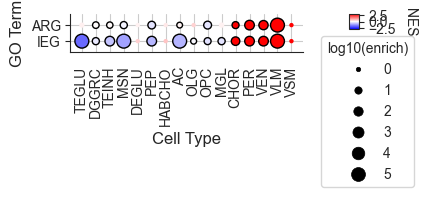

In [76]:
# Set up the figure
# plt.figure(figsize=(3, 5))
plt.figure(figsize=(3, .5))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=top_terms_df,
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor=None,
    linewidth=0,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

sns.scatterplot(
    data=top_terms_df.loc[top_terms_df['FDR q-val'] < 0.05].copy(),
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor='black',
    linewidth=1,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

plt.grid()
sns.despine()

# col colors 
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 
ctype_colors = [adata.uns['level_2_color_dict'][ctype] for ctype in top_terms_df['ctype'].unique()]
for i, color in enumerate(ctype_colors):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.02), width=1, height=.015, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
size_values = [0, 1, 2, 3, 4, 5]  # Representative size values
size_labels = ['0', '1', '2', '3', '4', '5']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 10 + (size_val - 0) / (5 - 0) * (100 - 10)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add colorbar for NES values
norm = Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

cax = bubble_plot.inset_axes([1.2, .6, 0.04, .4])
cbar = plt.colorbar(sm, ax=plt.gca(), cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('NES', rotation=270, labelpad=15)

# Customize the plot
bubble_plot.set_xlabel('Cell Type', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
# plt.margins(x=0.02, y=0.03)
plt.margins(x=0.02, y=.7)

plt.savefig(os.path.join(fig_path, f'l2_gsea_custom_star.pdf'), bbox_inches='tight', dpi=100)
# plt.savefig(os.path.join(fig_path, f'l2_gsea_star.pdf'), bbox_inches='tight', dpi=100)
plt.show()

##### level 3 - neuron

In [148]:
current_protocol = 'RIBO'
neuron_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 
                'TEGLU_CA', 'DEGLU', 'MSN_1', 'MSN_2', 'PEP', 'HABCHO',
                'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']
current_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'{current_protocol}_combined.csv'), index_col=0)
# current_res_df = current_res_df.loc[current_res_df['FDR q-val'] < 0.05, :]
current_res_df = current_res_df.loc[current_res_df['ctype'].isin(neuron_list), :]
current_res_df = current_res_df.loc[current_res_df['Term'].str.contains('GO_'), :]
current_res_df['Term'] = current_res_df['Term'].str.replace('GO_', '')
current_res_df['Term'] = current_res_df['Term'].str.replace('_', ' ')
current_res_df['Term'] = current_res_df['Term'].str.capitalize()
current_res_df['Term_size'] = current_res_df['Tag %'].str.split('/').str[0]
current_res_df['Term_size'] = current_res_df['Term_size'].astype(int)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df['ctype'] = current_res_df['ctype'].astype('category')
current_res_df['ctype'] = current_res_df['ctype'].cat.reorder_categories(neuron_list)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Regulation of chromosome separation,0.659039,1.938455,0.002000,0.371897,0.539,6/16,10.53%,DUSP1;ATM;RB1;CUL3;HECW2;XRCC3,DEGLU,RIBO,up,6
1,gsea,Positive regulation of myeloid leukocyte diffe...,0.599689,1.896664,0.000000,0.296694,0.670,11/21,15.03%,RB1;ID2;CD74;JUN;TRIB1;KLF10;IL23A;TYROBP;TMEM...,DEGLU,RIBO,up,11
2,gsea,Positive regulation of neuron apoptotic process,0.590713,1.863027,0.006024,0.285705,0.776,10/19,16.19%,ATM;TGFB2;CDK5;JUN;HDAC4;ITGA1;CCL3;TYROBP;ASC...,DEGLU,RIBO,up,10
3,gsea,Positive regulation of cell cycle arrest,0.617468,1.802144,0.007576,0.400828,0.912,7/15,13.37%,BTG2;ATM;ID2;BRCA1;RNF112;CNOT6;EP300,DEGLU,RIBO,up,7
4,gsea,Positive regulation of notch signaling pathway,0.563763,1.756536,0.005952,0.501495,0.957,10/20,16.39%,KAT2B;TGFB2;HES5;STAT3;ASCL1;DLL4;ROBO2;EP300;...,DEGLU,RIBO,up,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35975,gsea,Cell adhesion mediator activity,-0.173072,-0.567973,0.976285,0.988489,1.000,9/24,37.38%,LRRC4C;BSG;CDC42EP1;BAIAP2L1;ITGB1;PLXNB3;PDLI...,TEINH_4,RIBO,down,9
35976,gsea,Nerve development,-0.147458,-0.545327,0.993902,0.992331,1.000,23/38,50.84%,GABRA5;NTF3;EGR2;SLC1A3;PLXNA4;PHOX2B;UNC13A;N...,TEINH_4,RIBO,down,23
35977,gsea,Positive regulation of interleukin 6 production,-0.183071,-0.542733,0.978088,0.992414,1.000,10/17,52.23%,STAT3;UCN;TLR3;MBP;LBP;TNF;LPL;C1QTNF4;ARHGEF2...,TEINH_4,RIBO,down,10
35978,gsea,Collagen biosynthetic process,-0.175051,-0.523759,0.982353,0.994611,1.000,10/17,55.66%,LARP6;UCN;WNT4;ADAMTS3;P3H3;NPPC;ARRB2;CREB3L1...,TEINH_4,RIBO,down,10


In [ ]:
# star
selected_terms = [
    'Potassium channel activity',
    'Presynapse',
    'Postsynaptic membrane',
    'Glutamatergic synapse',
    'Gaba ergic synapse',
    'Glutamate receptor signaling pathway',
    'Negative regulation of synaptic transmission',
    'Axonal transport',
    'Ribosome biogenesis',
    'Translational initiation',
    'Protein localization to synapse',
    'Regulation of axonogenesis',
    'Tight junction',
]

In [151]:
# ribo
selected_terms = [
    'Neuron to neuron synapse',
    'Synapse organization',
    'Glutamatergic synapse',
    'Regulation of neurotransmitter levels',
    'Regulation of neurotransmitter receptor activity',
    'Gaba ergic synapse',
    'Neuropeptide hormone activity',
    'Glutamate receptor signaling pathway',
    'Dopamine receptor signaling pathway',
    'Oxidative phosphorylation',
    'Ribosome',
    'Protein localization to membrane',
    'Protein folding',
]

In [152]:
current_res_df = current_res_df.loc[current_res_df['Term'].isin(selected_terms), :]
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(selected_terms)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Protein folding,-0.586284,-2.197253,0.000000,0.003929,0.026,17/45,17.64%,GNAO1;CALR;DNAJA4;DNAJA1;HSPA5;DNAJB5;PDIA4;GN...,DEGLU,RIBO,down,17
1,gsea,Protein localization to membrane,-0.457726,-2.151592,0.000000,0.006041,0.053,85/151,37.60%,PPP1R9B;DPP10;PAK1;MRAP2;BSG;APOE;REEP1;ANK3;T...,DEGLU,RIBO,down,85
2,gsea,Oxidative phosphorylation,-0.641397,-2.097280,0.000000,0.008699,0.102,9/25,10.10%,CHCHD10;COX7A2;NDUFA4;COX6A2;SNCA;NDUFC1;SLC25...,DEGLU,RIBO,down,9
3,gsea,Neuron to neuron synapse,-0.431353,-2.057339,0.000000,0.008837,0.171,61/184,27.76%,RHEB;CAMK2A;RTN4;ATP1A3;PPP1R9B;BSN;MAPK1;PJA2...,DEGLU,RIBO,down,61
4,gsea,Dopamine receptor signaling pathway,-0.570071,-1.829436,0.003929,0.025054,0.865,5/22,8.36%,GNAO1;RGS4;KLF16;GNB5;GNG2,DEGLU,RIBO,down,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177,gsea,Dopamine receptor signaling pathway,-0.575228,-1.820215,0.002016,0.026355,0.875,7/22,17.01%,GNAO1;GNB5;GNG2;RGS4;PALM;RGS8;KLF16,TEINH_4,RIBO,down,7
178,gsea,Neuropeptide hormone activity,-0.521047,-1.708241,0.009921,0.044338,0.990,9/24,27.92%,CCK;VIP;GRP;CORT;PENK;UCN;NPY;PRLH;PYY,TEINH_4,RIBO,down,9
179,gsea,Regulation of neurotransmitter receptor activity,-0.438832,-1.691178,0.002151,0.047846,0.993,23/49,39.32%,ARC;NPTXR;SHISA6;NETO1;DLGAP3;CACNG8;LYNX1;LRR...,TEINH_4,RIBO,down,23
180,gsea,Glutamate receptor signaling pathway,-0.302889,-1.238898,0.151020,0.269981,1.000,28/65,39.32%,ARC;SHISA6;NETO1;CACNG8;KCNB1;GRM8;LRRC7;SHANK...,TEINH_4,RIBO,down,28


In [94]:
adata.obs['level_3_label'] = adata.obs['level_3'].str.split('-').str[0]
adata.obs['level_3_label'] = adata.obs['level_3_label'].str.replace('/', '_')
adata.obs['level_3_label'] = adata.obs['level_3_label'].astype('category')

In [95]:
adata.uns['level_3_label_color_dict'] = {
 'AC_1': '#eaeaa2',
 'AC_2': '#bcbc5e',
 'AC_3': '#a6a64d',
 'CHOR': '#7f52a9',
 'DEGLU': '#f78a88',
 'DGGRC': '#295029',
 'HABCHO': '#f29ed8',
 'MGL': '#a2b1d8',
 'MSN_1': '#7aecf8',
 'MSN_2': '#06a6cf',
 'Mix': '#dddddd',
 'OLG_1': '#a8e1eb',
 'OLG_2': '#7dc7d5',
 'OLG_3': '#61b2c1',
 'OPC': '#667872',
 'PEP': '#ed5e5b',
 'PER': '#c49c94',
 'TEGLU_CA': '#00e846',
 'TEGLU_L2_3': '#c4ff45',
 'TEGLU_L4_5': '#9ee800',
 'TEGLU_L5_6': '#32a630',
 'TEGLU_L6': '#316e10',
 'TEGLU_Mix': '#2c642c',
 'TEINH_1': '#fcd02d',
 'TEINH_2': '#fead65',
 'TEINH_3': '#ffdcbd',
 'TEINH_4': '#b76319',
 'VEN': '#8e6d61',
 'VLM_1': '#1f76b3',
 'VLM_2': '#246693',
 'VSM': '#774d44'}

In [153]:
expr_list = []
for i in tqdm(range(current_res_df.shape[0])):
# for i in tqdm(range(1)):
    current_genes = current_res_df.loc[i, 'Lead_genes']
    current_genes = current_genes.split(';')
    current_genes = [gene.strip().capitalize() for gene in current_genes]
    current_ctype = current_res_df.loc[i, 'ctype']
    current_expr = adata[adata.obs['level_3_label'] == current_ctype, current_genes].layers['log2_norm1e4'].copy()
    current_expr = current_expr.toarray().mean()
    expr_list.append(current_expr)
current_res_df['expr'] = expr_list

  0%|          | 0/182 [00:00<?, ?it/s]

In [154]:
# Group by 'key' (cell type) and select the top 3 terms for each
expr_threshold = current_res_df['expr'].quantile(0.3) # l2 0.5
# top_terms_df = current_res_df.loc[(current_res_df['Term_size'] > 10) & (current_res_df['expr'] > expr_threshold)].copy()
# top_terms_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['expr'] > expr_threshold)].copy()
top_terms_df = current_res_df.loc[(current_res_df['expr'] > expr_threshold)].copy()

# Add columns for visualization
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))


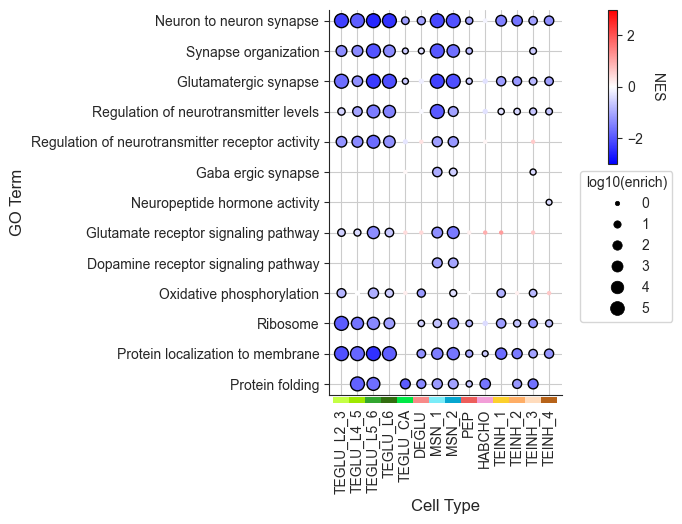

In [156]:
# Set up the figure
plt.figure(figsize=(3, 5))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=top_terms_df,
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor=None,
    linewidth=0,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

sns.scatterplot(
    data=top_terms_df.loc[top_terms_df['FDR q-val'] < 0.05].copy(),
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor='black',
    linewidth=1,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

plt.grid()
sns.despine()

# col colors 
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 
ctype_colors = [adata.uns['level_3_label_color_dict'][ctype] for ctype in top_terms_df['ctype'].cat.categories]
for i, color in enumerate(ctype_colors):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.02), width=1, height=.015, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
size_values = [0, 1, 2, 3, 4, 5]  # Representative size values
size_labels = ['0', '1', '2', '3', '4', '5']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 10 + (size_val - 0) / (5 - 0) * (100 - 10)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add colorbar for NES values
norm = Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

cax = bubble_plot.inset_axes([1.2, .6, 0.04, .4])
cbar = plt.colorbar(sm, ax=plt.gca(), cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('NES', rotation=270, labelpad=15)

# Customize the plot
bubble_plot.set_xlabel('Cell Type', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
plt.margins(x=0.02, y=0.03)

plt.savefig(os.path.join(fig_path, f'l3_gsea_ribo.pdf'), bbox_inches='tight', dpi=100)
# plt.savefig(os.path.join(fig_path, f'l2_gsea_star.pdf'), bbox_inches='tight', dpi=100)
plt.show()

##### level 3 - glia

In [930]:
current_protocol = 'RIBO'
ctype_list = ['AC_1', 'AC_2', 'AC_3']
# ctype_list = ['OLG_1', 'OLG_2', 'OLG_3']
current_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'{current_protocol}_combined.csv'), index_col=0)
# current_res_df = current_res_df.loc[current_res_df['FDR q-val'] < 0.05, :]
current_res_df = current_res_df.loc[current_res_df['ctype'].isin(ctype_list), :]
current_res_df = current_res_df.loc[current_res_df['Term'].str.contains('GO_'), :]
current_res_df['Term'] = current_res_df['Term'].str.replace('GO_', '')
current_res_df['Term'] = current_res_df['Term'].str.replace('_', ' ')
current_res_df['Term'] = current_res_df['Term'].str.capitalize()
current_res_df['Term_size'] = current_res_df['Tag %'].str.split('/').str[0]
current_res_df['Term_size'] = current_res_df['Term_size'].astype(int)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df['ctype'] = current_res_df['ctype'].astype('category')
current_res_df['ctype'] = current_res_df['ctype'].cat.reorder_categories(ctype_list)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Regulation of chromosome separation,0.585795,1.758392,0.012500,1.000000,0.962,9/16,21.61%,ATM;XRCC3;KLHL22;RIOK2;DUSP1;UBE2C;CSNK2A2;HEC...,AC_1,RIBO,up,9
1,gsea,Positive regulation of neuron apoptotic process,0.489495,1.543377,0.022449,1.000000,1.000,11/19,25.50%,TGFB2;ATM;ASCL1;EPHA7;TYROBP;CDK5;MCL1;HDAC4;P...,AC_1,RIBO,up,11
2,gsea,Rna phosphodiester bond hydrolysis,0.528346,1.539095,0.032990,1.000000,1.000,4/15,14.65%,POLR3K;DCP2;RCL1;RPP21,AC_1,RIBO,up,4
3,gsea,B cell proliferation,0.463825,1.446114,0.064257,1.000000,1.000,10/19,19.93%,ABL1;CD74;ATM;NFATC2;CDKN1A;TYROBP;PLCL2;SLC39...,AC_1,RIBO,up,10
4,gsea,Nuclease activity,0.468086,1.435182,0.082803,1.000000,1.000,10/19,32.00%,DCP2;XRCC3;RCL1;DCLRE1A;RPP21;DXO;N4BP2;AGO3;A...,AC_1,RIBO,up,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7702,gsea,Calcium ion regulated exocytosis,-0.170868,-0.531665,0.988304,0.995514,1.000,10/21,46.24%,CDK5;RIMS1;KCNB1;DOC2A;UNC13A;SYN2;STX1A;STX1B...,AC_3,RIBO,down,10
7703,gsea,Phosphatidylinositol metabolic process,-0.137493,-0.521013,0.993865,0.996086,1.000,23/43,51.06%,FAM126B;HTR2C;PIGU;PLEKHA1;PIK3C2A;PIGV;RAB4A;...,AC_3,RIBO,down,23
7704,gsea,Endochondral bone morphogenesis,-0.161115,-0.516910,0.993590,0.996171,1.000,12/23,47.57%,BMP6;BMPR2;MEF2C;ANXA6;BMP4;SHOX2;ALPL;TGFBR2;...,AC_3,RIBO,down,12
7705,gsea,Recycling endosome membrane,-0.161973,-0.487691,0.987755,0.997511,1.000,11/16,46.24%,RAB35;VAMP8;SORL1;RAB4A;RAB8B;ABHD17A;CFTR;BOK...,AC_3,RIBO,down,11


In [931]:
# AC ribo
selected_terms = [
    'Glutamate secretion',
    'Tight junction',
    'Protein localization to membrane',
    'Long term synaptic potentiation',
    'Phospholipid biosynthetic process',
    'Regulation of cholesterol metabolic process',
    'Chaperone binding',
    'Protein targeting to membrane',
]

In [924]:
# OLG ribo
selected_terms = [
    'Axon',
    'Gtpase binding',
    # 'Cell cell adhesion',
    'Ensheathment of neurons',
    'Microtubule based movement',
    'Protein localization to membrane',
    'Regulation of intracellular signal transduction',
]

In [932]:
current_res_df = current_res_df.loc[current_res_df['Term'].isin(selected_terms), :]
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(selected_terms)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Protein localization to membrane,-0.498563,-2.361537,0.000000,0.000000,0.000,59/151,24.46%,APOE;BSG;PPP1R9B;RPS24;TMEM59;DPP10;RAP1A;HSPA...,AC_1,RIBO,down,59
1,gsea,Protein targeting to membrane,-0.604438,-2.228914,0.000000,0.004141,0.009,20/37,25.85%,RPS24;HSPA5;RPL32;RPS5;RPL17;PAK1;RPS12;RPL13A...,AC_1,RIBO,down,20
2,gsea,Chaperone binding,-0.615636,-2.133733,0.000000,0.007493,0.056,7/28,5.34%,HSPA8;CALR;DNAJA1;CLU;HSPA5;ATP1A3;DNAJA4,AC_1,RIBO,down,7
3,gsea,Glutamate secretion,-0.582303,-1.937297,0.000000,0.027111,0.517,8/24,13.37%,GJA1;SLC1A3;CCK;SLC38A2;NTRK2;NTSR1;APBA1;SLC17A7,AC_1,RIBO,down,8
4,gsea,Tight junction,-0.434955,-1.534525,0.019380,0.100847,1.000,9/34,17.75%,GJA1;CLDN11;AFDN;SYNPO;AMOTL2;CLDN5;MPDZ;LIN7C...,AC_1,RIBO,down,9
5,gsea,Regulation of cholesterol metabolic process,-0.384269,-1.343156,0.084337,0.176364,1.000,15/29,39.43%,APOE;GPAM;SREBF2;KPNB1;MVD;ACACA;ABCG1;DHCR7;A...,AC_1,RIBO,down,15
6,gsea,Long term synaptic potentiation,-0.305236,-1.203820,0.168582,0.279755,1.000,25/51,47.29%,APOE;FAM107A;MAPK1;NTRK2;SLC24A2;ARC;GRIN2C;ME...,AC_1,RIBO,down,25
7,gsea,Phospholipid biosynthetic process,-0.280530,-1.104333,0.293893,0.395499,1.000,26/56,40.18%,RAB4A;ABHD4;RUFY1;GPAM;DGKD;PIGU;PIK3C2A;TMEM3...,AC_1,RIBO,down,26
8,gsea,Long term synaptic potentiation,-0.628368,-2.457703,0.000000,0.000000,0.000,14/51,9.83%,ARC;NRGN;MAPK1;APOE;NTRK2;GRIN2C;FAM107A;SNAP4...,AC_2,RIBO,down,14
9,gsea,Protein localization to membrane,-0.514531,-2.418024,0.000000,0.000000,0.000,87/151,35.36%,APOE;HSPA5;RPL13A;RPS24;TMEM59;RPL32;PAK1;GRIN...,AC_2,RIBO,down,87


In [933]:
expr_list = []
for i in tqdm(range(current_res_df.shape[0])):
# for i in tqdm(range(1)):
    current_genes = current_res_df.loc[i, 'Lead_genes']
    current_genes = current_genes.split(';')
    current_genes = [gene.strip().capitalize() for gene in current_genes]
    current_ctype = current_res_df.loc[i, 'ctype']
    current_expr = adata[adata.obs['level_3_label'] == current_ctype, current_genes].layers['log2_norm1e4'].copy()
    current_expr = current_expr.toarray().mean()
    expr_list.append(current_expr)
current_res_df['expr'] = expr_list

  0%|          | 0/24 [00:00<?, ?it/s]

In [934]:
# Group by 'key' (cell type) and select the top 3 terms for each
expr_threshold = current_res_df['expr'].quantile(0.2) # l2 0.5
# top_terms_df = current_res_df.loc[(current_res_df['Term_size'] > 10) & (current_res_df['expr'] > expr_threshold)].copy()
# top_terms_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['expr'] > expr_threshold)].copy()
top_terms_df = current_res_df.loc[(current_res_df['expr'] > expr_threshold)].copy()

# Add columns for visualization
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))


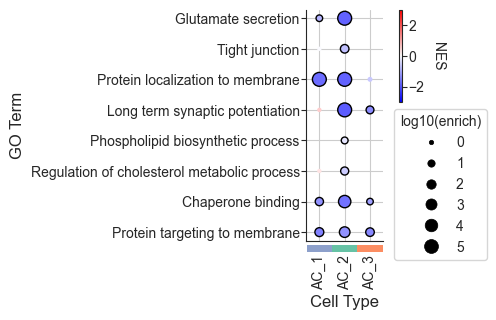

In [935]:
# Set up the figure
plt.figure(figsize=(1, 3))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=top_terms_df,
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor=None,
    linewidth=0,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

sns.scatterplot(
    data=top_terms_df.loc[top_terms_df['FDR q-val'] < 0.05].copy(),
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor='black',
    linewidth=1,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

plt.grid()
sns.despine()

# col colors 
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 
for i, color in enumerate(['#8DA0CB', '#66C2A5', '#FC8D62']):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.05), width=1, height=.03, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
size_values = [0, 1, 2, 3, 4, 5]  # Representative size values
size_labels = ['0', '1', '2', '3', '4', '5']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 10 + (size_val - 0) / (5 - 0) * (100 - 10)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add colorbar for NES values
norm = Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

cax = bubble_plot.inset_axes([1.2, .6, 0.04, .4])
cbar = plt.colorbar(sm, ax=plt.gca(), cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('NES', rotation=270, labelpad=15)

# Customize the plot
bubble_plot.set_xlabel('Cell Type', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
plt.margins(x=0.01, y=0.04)

plt.savefig(os.path.join(fig_path, f'l3_ac_gsea_ribo.pdf'), bbox_inches='tight', dpi=100)
# plt.savefig(os.path.join(fig_path, f'l2_gsea_star.pdf'), bbox_inches='tight', dpi=100)
plt.show()

##### PER & VEN

In [25]:
ctype_list = ['PER', 'VEN']
ribo_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'RIBO_combined.csv'), index_col=0)
star_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'STAR_combined.csv'), index_col=0)

# current_res_df = current_res_df.loc[current_res_df['FDR q-val'] < 0.05, :]
def modify_res_df(current_res_df, ctype_list):
    current_res_df = current_res_df.loc[current_res_df['ctype'].isin(ctype_list), :]
    current_res_df = current_res_df.loc[current_res_df['Term'].str.contains('GO_'), :]
    current_res_df['Term'] = current_res_df['Term'].str.replace('GO_', '')
    current_res_df['Term'] = current_res_df['Term'].str.replace('_', ' ')
    current_res_df['Term'] = current_res_df['Term'].str.capitalize()
    current_res_df['Term_size'] = current_res_df['Tag %'].str.split('/').str[0]
    current_res_df['Term_size'] = current_res_df['Term_size'].astype(int)
    current_res_df = current_res_df.reset_index(drop=True)
    current_res_df['ctype'] = current_res_df['ctype'].astype('category')
    current_res_df['ctype'] = current_res_df['ctype'].cat.reorder_categories(ctype_list)
    return current_res_df
ribo_res_df = modify_res_df(ribo_res_df, ctype_list)
star_res_df = modify_res_df(star_res_df, ctype_list)

In [34]:
# terms
star_selected_terms = [
    'Fibroblast migration',
    'Cellular response to starvation',
    'Positive regulation of apoptotic signaling pathway',
    'Tight junction',
]

ribo_selected_terms = [
    'Positive regulation of extrinsic apoptotic signaling pathway',
    'Skeletal muscle cell differentiation',
    'Protein localization to membrane',

]
selected_terms = star_selected_terms + ribo_selected_terms

In [35]:
current_res_df = pd.concat([star_res_df.loc[star_res_df['Term'].isin(star_selected_terms), :], ribo_res_df.loc[ribo_res_df['Term'].isin(ribo_selected_terms), :]], axis=0)
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(selected_terms)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Fibroblast migration,0.722887,2.169808,0.000000,0.005038,0.029,6/17,9.32%,AKAP12;SGPL1;ITGB1;TNS1;IQGAP1;ILK,PER,STAR,up,6
1,gsea,Cellular response to starvation,0.550432,2.153616,0.000000,0.005363,0.039,12/50,11.26%,SLC2A1;KLF10;SIK1;ATF3;SLC38A2;ATF4;JUN;RRAGB;...,PER,STAR,up,12
2,gsea,Positive regulation of apoptotic signaling pat...,0.564758,2.119387,0.000000,0.007898,0.069,9/43,8.18%,TNFRSF12A;ATF3;MCL1;TIMP3;SKIL;BCL2L1;PRKCD;RP...,PER,STAR,up,9
3,gsea,Tight junction,-0.643192,-2.331281,0.000000,0.001513,0.001,18/33,22.34%,AFDN;CGNL1;GJA1;ARHGEF2;MPDZ;AMOT;PDCD6IP;SIPA...,PER,STAR,down,18
4,gsea,Positive regulation of apoptotic signaling pat...,0.449694,1.700399,0.007477,0.627375,0.991,14/43,22.23%,TIMP3;TNFRSF12A;ATF3;MCL1;RPS7;CTSC;INHBA;SKIL...,VEN,STAR,up,14
5,gsea,Cellular response to starvation,0.393658,1.537868,0.013233,0.557952,1.000,50/50,99.77%,SIK1;JUN;SLC2A1;ATF3;ATF4;KLF10;SLC38A2;CLEC16...,VEN,STAR,up,50
6,gsea,Fibroblast migration,0.409705,1.255285,0.202505,0.678951,1.000,7/17,23.27%,AKAP12;ILK;IQGAP1;PAK3;PRKCE;ITGB1;AKT1,VEN,STAR,up,7
7,gsea,Tight junction,-0.544691,-1.906060,0.000000,0.092308,0.648,17/34,24.46%,CGNL1;SAPCD2;AMOTL2;SIPA1L3;AFDN;GJA1;STRN;MPD...,VEN,STAR,down,17
8,gsea,Positive regulation of extrinsic apoptotic sig...,0.776008,2.330450,0.000000,0.000541,0.002,4/18,0.61%,TNFRSF12A;TIMP3;ATF3;MAL,PER,RIBO,up,4
9,gsea,Skeletal muscle cell differentiation,0.686193,2.030111,0.000000,0.020372,0.242,6/18,6.93%,BTG2;FOS;ATF3;EGR1;FOXN2;PHOX2B,PER,RIBO,up,6


In [36]:
expr_list = []
for i in tqdm(range(current_res_df.shape[0])):
# for i in tqdm(range(1)):
    current_genes = current_res_df.loc[i, 'Lead_genes']
    current_genes = current_genes.split(';')
    current_genes = [gene.strip().capitalize() for gene in current_genes]
    current_ctype = current_res_df.loc[i, 'ctype']
    current_expr = adata[adata.obs['level_3_label'] == current_ctype, current_genes].layers['log2_norm1e4'].copy()
    current_expr = current_expr.toarray().mean()
    expr_list.append(current_expr)
current_res_df['expr'] = expr_list

  0%|          | 0/14 [00:00<?, ?it/s]

In [37]:
# Group by 'key' (cell type) and select the top 3 terms for each
expr_threshold = current_res_df['expr'].quantile(0.2) # l2 0.5
# top_terms_df = current_res_df.loc[(current_res_df['Term_size'] > 10) & (current_res_df['expr'] > expr_threshold)].copy()
# top_terms_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['expr'] > expr_threshold)].copy()
top_terms_df = current_res_df.loc[(current_res_df['expr'] > expr_threshold)].copy()

# Add columns for visualization
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))


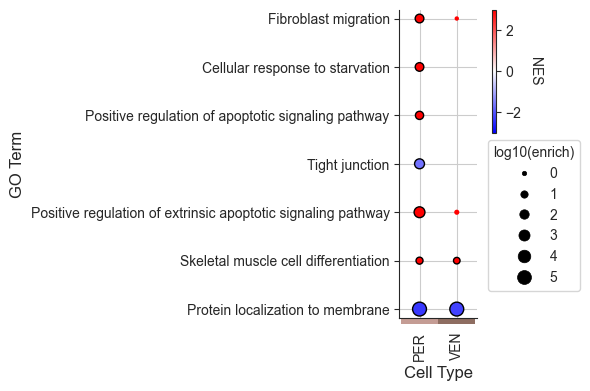

In [43]:
# Set up the figure
plt.figure(figsize=(1, 4))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=top_terms_df,
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor=None,
    linewidth=0,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

sns.scatterplot(
    data=top_terms_df.loc[top_terms_df['FDR q-val'] < 0.05].copy(),
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor='black',
    linewidth=1,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

plt.grid()
sns.despine()

# col colors 
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 
ctype_colors = [adata.uns['level_3_label_color_dict'][ctype] for ctype in top_terms_df['ctype'].cat.categories]
for i, color in enumerate(ctype_colors):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.02), width=1, height=.015, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
size_values = [0, 1, 2, 3, 4, 5]  # Representative size values
size_labels = ['0', '1', '2', '3', '4', '5']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 10 + (size_val - 0) / (5 - 0) * (100 - 10)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add colorbar for NES values
norm = Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

cax = bubble_plot.inset_axes([1.2, .6, 0.04, .4])
cbar = plt.colorbar(sm, ax=plt.gca(), cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('NES', rotation=270, labelpad=15)

# Customize the plot
bubble_plot.set_xlabel('Cell Type', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
plt.margins(x=0.02, y=0.03)

plt.savefig(os.path.join(fig_path, f'l3_gsea_per_ven.pdf'), bbox_inches='tight', dpi=100)
# plt.savefig(os.path.join(fig_path, f'l2_gsea_star.pdf'), bbox_inches='tight', dpi=100)
plt.show()

##### all

In [74]:
ctype_list = ['AC_1', 'AC_2', 'AC_3',
              'OLG_1', 'OLG_2', 'OLG_3',
              'PER', 'VEN']
ribo_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'RIBO_combined.csv'), index_col=0)
star_res_df = pd.read_csv(os.path.join(output_path, "gsea", "l3_expr", f'STAR_combined.csv'), index_col=0)

# current_res_df = current_res_df.loc[current_res_df['FDR q-val'] < 0.05, :]
def modify_res_df(current_res_df, ctype_list):
    current_res_df = current_res_df.loc[current_res_df['ctype'].isin(ctype_list), :]
    current_res_df = current_res_df.loc[current_res_df['Term'].str.contains('GO_'), :]
    current_res_df['Term'] = current_res_df['Term'].str.replace('GO_', '')
    current_res_df['Term'] = current_res_df['Term'].str.replace('_', ' ')
    current_res_df['Term'] = current_res_df['Term'].str.capitalize()
    current_res_df['Term_size'] = current_res_df['Tag %'].str.split('/').str[0]
    current_res_df['Term_size'] = current_res_df['Term_size'].astype(int)
    current_res_df = current_res_df.reset_index(drop=True)
    current_res_df['ctype'] = current_res_df['ctype'].astype('category')
    current_res_df['ctype'] = current_res_df['ctype'].cat.reorder_categories(ctype_list)
    return current_res_df
ribo_res_df = modify_res_df(ribo_res_df, ctype_list)
star_res_df = modify_res_df(star_res_df, ctype_list)

In [75]:
ribo_selected_terms = [
    # ac
    'Axon',
    'Gtpase binding',
    'Chaperone binding',
    'Glutamate secretion',
    'Protein localization to membrane',
    'Long term synaptic potentiation',
    'Phospholipid biosynthetic process',
    'Regulation of cholesterol metabolic process',

    # olg
    'Ensheathment of neurons',
    'Microtubule based movement',
    # 'Regulation of intracellular signal transduction',
    'Tight junction',

    # per
    'Skeletal muscle cell differentiation',
    'Positive regulation of extrinsic apoptotic signaling pathway',
]

star_selected_terms = [
    'Fibroblast migration',
    'Cellular response to starvation',
    'Positive regulation of apoptotic signaling pathway',
]

selected_terms = ribo_selected_terms + star_selected_terms

In [76]:
current_res_df = pd.concat([star_res_df.loc[star_res_df['Term'].isin(star_selected_terms), :], ribo_res_df.loc[ribo_res_df['Term'].isin(ribo_selected_terms), :]], axis=0)
current_res_df['Term'] = current_res_df['Term'].astype('category')
current_res_df['Term'] = current_res_df['Term'].cat.reorder_categories(selected_terms)
current_res_df = current_res_df.reset_index(drop=True)
current_res_df

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,ctype,protocol,direction,Term_size
0,gsea,Fibroblast migration,0.275338,0.820700,0.704280,1.000000,1.000,17/17,96.08%,AKAP12;CCN3;PRR5L;SDC4;SLC8A1;PAK1;PRKCE;IQGAP...,AC_1,STAR,up,17
1,gsea,Cellular response to starvation,-0.335327,-1.313620,0.072874,0.191393,1.000,19/50,36.23%,HSPA8;HSPA5;CARTPT;CPEB4;GAS2L1;ATG5;ASNS;MAP3...,AC_1,STAR,down,19
2,gsea,Positive regulation of apoptotic signaling pat...,-0.259516,-1.010648,0.422764,0.522851,1.000,25/43,51.55%,BMPR1B;CHCHD10;TIMP3;APAF1;ADORA2A;RET;JAK2;BC...,AC_1,STAR,down,25
3,gsea,Fibroblast migration,0.482403,1.452290,0.069170,0.762904,1.000,10/17,21.44%,ILK;SGPL1;PRKCE;CCN3;AKAP12;PAK1;PAK3;AKT1;PRR...,AC_2,STAR,up,10
4,gsea,Cellular response to starvation,-0.372260,-1.456015,0.031746,0.183088,1.000,24/50,40.88%,HSPA8;HSPA5;CPEB4;CARTPT;GCGR;SREBF2;DAPL1;MAP...,AC_2,STAR,down,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,gsea,Chaperone binding,-0.547536,-1.876475,0.002037,0.012609,0.746,13/28,26.02%,CALR;HSPA8;GNB5;CLU;ATP1A3;ATP1A1;DNAJA1;KSR1;...,VEN,RIBO,down,13
124,gsea,Gtpase binding,-0.346488,-1.660909,0.000000,0.035894,0.997,69/157,36.23%,PAK1;ARHGEF19;DMXL2;ARHGEF26;BCR;WASF1;MYO1C;R...,VEN,RIBO,down,69
125,gsea,Regulation of cholesterol metabolic process,-0.393175,-1.355979,0.090909,0.136013,1.000,14/29,42.53%,APOE;HMGCS1;ABCG1;NFYB;FDFT1;MVD;FGF1;KPNB1;GP...,VEN,RIBO,down,14
126,gsea,Ensheathment of neurons,-0.323474,-1.260233,0.125257,0.198272,1.000,17/48,32.03%,CLU;ID4;NTRK2;CLDN11;KCNJ10;POU3F1;MBP;EGR2;LG...,VEN,RIBO,down,17


In [77]:
expr_list = []
for i in tqdm(range(current_res_df.shape[0])):
# for i in tqdm(range(1)):
    current_genes = current_res_df.loc[i, 'Lead_genes']
    current_genes = current_genes.split(';')
    current_genes = [gene.strip().capitalize() for gene in current_genes]
    current_ctype = current_res_df.loc[i, 'ctype']
    current_expr = adata[adata.obs['level_3_label'] == current_ctype, current_genes].layers['log2_norm1e4'].copy()
    current_expr = current_expr.toarray().mean()
    expr_list.append(current_expr)
current_res_df['expr'] = expr_list

  0%|          | 0/128 [00:00<?, ?it/s]

In [78]:
# Group by 'key' (cell type) and select the top 3 terms for each
expr_threshold = current_res_df['expr'].quantile(0.2) # l2 0.5
# top_terms_df = current_res_df.loc[(current_res_df['Term_size'] > 10) & (current_res_df['expr'] > expr_threshold)].copy()
# top_terms_df = current_res_df.loc[(current_res_df['FDR q-val'] < 0.05) & (current_res_df['expr'] > expr_threshold)].copy()
top_terms_df = current_res_df.loc[(current_res_df['expr'] > expr_threshold)].copy()

# Add columns for visualization
top_terms_df['-log10(FDR)'] = -top_terms_df['FDR q-val'].apply(lambda x: np.log10(x+1e-5))


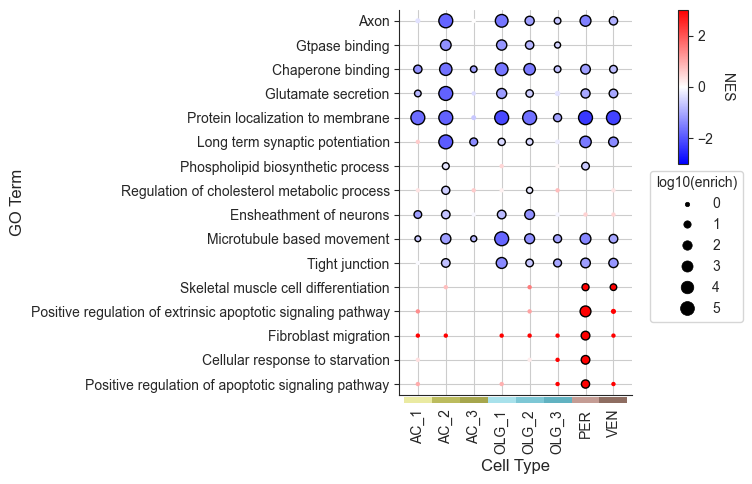

In [86]:
# Set up the figure
plt.figure(figsize=(3, 5))
sns.set_style("ticks")

# Create the bubble plot with continuous color mapping (keep your original data)
bubble_plot = sns.scatterplot(
    data=top_terms_df,
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor=None,
    linewidth=0,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

sns.scatterplot(
    data=top_terms_df.loc[top_terms_df['FDR q-val'] < 0.05].copy(),
    x='ctype',  
    y='Term',  
    size='-log10(FDR)',
    hue='NES',
    palette='bwr',
    sizes=(10, 100),
    edgecolor='black',
    linewidth=1,
    hue_norm=(-3, 0),
    size_norm=(1, 5),
)

plt.grid()
sns.despine()

# col colors 
bubble_plot.tick_params(axis='x', which='major', pad=10, length=0) 
ctype_colors = [adata.uns['level_3_label_color_dict'][ctype] for ctype in top_terms_df['ctype'].cat.categories]
for i, color in enumerate(ctype_colors):
    bubble_plot.add_patch(plt.Rectangle(xy=(i-0.5, -0.02), width=1, height=.015, color=color, lw=0,
                               transform=bubble_plot.get_xaxis_transform(), clip_on=False))
    
    

# Remove the default legend
bubble_plot.legend_.remove()

# Create custom discrete color legend
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Create size legend elements (get from original plot)
handles, labels = plt.gca().get_legend_handles_labels()
size_handles = []
size_labels = []

# Extract size information from the scatter collection
scatter = bubble_plot.collections[0]
sizes = scatter.get_sizes()
unique_sizes = sorted(list(set(sizes)))

# Create size legend with representative sizes
size_legend_elements = []
size_values = [0, 1, 2, 3, 4, 5]  # Representative size values
size_labels = ['0', '1', '2', '3', '4', '5']

for size_val, size_label in zip(size_values, size_labels):
    # Calculate actual marker size (seaborn uses different scaling)
    marker_size = 10 + (size_val - 0) / (5 - 0) * (100 - 10)
    size_legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
               markersize=np.sqrt(marker_size), markeredgecolor='black', 
               markeredgewidth=0.5, label=size_label)
    )

# Add legends to the plot
size_legend = plt.legend(handles=size_legend_elements, 
                        title='log10(enrich)', 
                        bbox_to_anchor=(1.05, 0.6), 
                        loc='upper left', 
                        fontsize=10,
                        frameon=True)

# Add colorbar for NES values
norm = Normalize(vmin=-3, vmax=3)
sm = cm.ScalarMappable(cmap='bwr', norm=norm)
sm.set_array([])

cax = bubble_plot.inset_axes([1.2, .6, 0.04, .4])
cbar = plt.colorbar(sm, ax=plt.gca(), cax=cax, shrink=0.8, aspect=20, pad=0.02)
cbar.set_label('NES', rotation=270, labelpad=15)

# Customize the plot
bubble_plot.set_xlabel('Cell Type', fontsize=12)
bubble_plot.set_ylabel('GO Term', fontsize=12)
bubble_plot.set_xticklabels(bubble_plot.get_xticklabels(), rotation=90, fontsize=10)
bubble_plot.set_yticklabels(bubble_plot.get_yticklabels(), fontsize=10)
plt.margins(x=0.02, y=0.03)

plt.savefig(os.path.join(fig_path, f'l3_gsea_all.pdf'), bbox_inches='tight', dpi=100)
# plt.savefig(os.path.join(fig_path, f'l2_gsea_star.pdf'), bbox_inches='tight', dpi=100)
plt.show()